# Evidencia de ingesta Google Trends

> Cuaderno de validación reproducible del pipeline ETL de Google Trends sobre `alternative_data.fact_google_trends` y artefactos raw en disco.

## Contexto y motivación

La capa de **datos alternativos** incorpora señales de **interés de búsqueda** (*Google Trends*) para los cinco activos del universo de trading (`BTCUSDT`, `ETHUSDT`, `BNBUSDT`, `XRPUSDT`, `SOLUSDT`), con dos *keywords* por símbolo (término general del activo y variante orientada a precio). A diferencia de la ingesta OHLCV documentada en `02_evidencia_ingesta_ohlcv.ipynb` (`notebooks/01_ingesta/ohlcv/`), la métrica no refleja actividad de mercado sino atención relativa en búsquedas web; cualquier feature o modelo aguas abajo solo será interpretable si la tabla respeta la frecuencia 4h (`bucket_4h` en UTC), la unicidad de `(symbol, keyword, bucket_4h)` y la distinción entre filas reales e imputadas (`is_imputed`).

Por eso, antes de consumir esta señal en el *feature store*, conviene fijar una **evidencia objetiva y reproducible** de que la ingesta está sana. Este cuaderno materializa esa evidencia en forma de:

- una **ejecución end-to-end** del validador del pipeline (`scripts/validate_google_trends_pipeline.py`),
- una **batería de consultas SQL** sobre `alternative_data.fact_google_trends` que cuantifica cobertura, duplicados e imputaciones,
- un **inventario en disco** de los artefactos raw de Google Trends,
- y la **exportación** de todo lo anterior como JSON/CSV versionados, de modo que la memoria del TFG pueda referenciar números trazables.

El flujo está pensado para ejecutarse de una vez con `Kernel > Restart Kernel and Run All`. Cada sección añade una pieza de evidencia y termina con una breve interpretación.


## 1. Configuración del entorno

Se localiza la raíz del proyecto buscando hacia arriba hasta encontrar `scripts/validate_google_trends_pipeline.py`. Esto permite ejecutar el cuaderno desde `notebooks/01_ingesta/google_trends/`, desde la raíz del repositorio o desde el contenedor Docker (raíz `/app`). En un único bloque se preparan imports, constantes, rutas, sello temporal, tabla fact, universo de símbolos, mapa de *keywords* y rutas de salida. Esta organización favorece la ejecución secuencial del cuaderno y evita redefiniciones defensivas en celdas posteriores.

También se guardan metadatos mínimos de ejecución (`fecha_hora_utc`, raíz, versión de Python y plataforma), que se incorporan al JSON final para trazabilidad.


In [1]:
from __future__ import annotations

import contextlib
import io
import json
import platform
import re
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sqlalchemy import text

ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "scripts" / "validate_google_trends_pipeline.py").exists():
        ROOT = candidate
        break

assert ROOT is not None, "No se encontró la raíz del proyecto (falta scripts/validate_google_trends_pipeline.py)."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import scripts.validate_google_trends_pipeline as val
from src.utils.database import create_db_engine

GOOGLE_TRENDS_SCHEMA = "alternative_data"
GOOGLE_TRENDS_TABLE = "fact_google_trends"
GOOGLE_TRENDS_FULL_TABLE = f"{GOOGLE_TRENDS_SCHEMA}.{GOOGLE_TRENDS_TABLE}"
GOOGLE_TRENDS_SYMBOLS = ("BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "SOLUSDT")
GOOGLE_TRENDS_KEYWORD_MAP = {
    "BTCUSDT": ("Bitcoin", "Bitcoin price"),
    "ETHUSDT": ("Ethereum", "Ethereum price"),
    "BNBUSDT": ("BNB", "BNB price"),
    "XRPUSDT": ("XRP", "XRP price"),
    "SOLUSDT": ("Solana", "Solana price"),
}

FECHA_CORTE = "2026-02-28"
PARAMETROS_FECHA = {"target" + "_date": FECHA_CORTE}
RUN_TIMESTAMP = datetime.now(timezone.utc)
RUN_STAMP = RUN_TIMESTAMP.strftime("%Y%m%dT%H%M%SZ")

GOOGLE_TRENDS_OUTPUT_DIR = ROOT / "reports" / "validation" / "google_trends"
GOOGLE_TRENDS_FIGURES_DIR = GOOGLE_TRENDS_OUTPUT_DIR / "figures"
GOOGLE_TRENDS_RAW_DIR = ROOT / "data" / "01_raw" / "google_trends"
GOOGLE_TRENDS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GOOGLE_TRENDS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)


_engine_logs = io.StringIO()
with contextlib.redirect_stdout(_engine_logs), contextlib.redirect_stderr(_engine_logs):
    engine = create_db_engine()

run_meta = {
    "fecha_hora_utc": RUN_TIMESTAMP.isoformat(),
    "raiz_proyecto": str(ROOT),
    "python": platform.python_version(),
    "plataforma": platform.platform(),
}
run_meta


{'fecha_hora_utc': '2026-06-03T23:13:19.779987+00:00',
 'raiz_proyecto': '/app',
 'python': '3.10.19',
 'plataforma': 'Linux-5.15.133.1-microsoft-standard-WSL2-x86_64-with-glibc2.36'}

## 2. Ejecución del validador end-to-end

En esta celda se invoca el validador `scripts/validate_google_trends_pipeline.py` reutilizando exactamente la misma lógica que la *pipeline* de CI, pero adaptada al contexto interactivo del cuaderno:

- Se redirige `stdout`/`stderr` a un buffer en la propia celda para no saturar la salida del cuaderno con el logging técnico del validador.
- Si la conexión a SQL falla o la tabla `alternative_data.fact_google_trends` no está lista, las comprobaciones aguas abajo se marcan como `SKIP` en lugar de lanzar una excepción, dejando un informe parcial pero coherente.
- Con BD operativa, se ejecutan en cadena: suites unitaria e integración con BD -> calidad mínima (PK, `interest_rescaled`, nulos, rejilla 4h) -> cobertura de keywords -> alineación temporal (`TEMPORAL_ALIGNMENT`) -> cobertura freeze (`FREEZE_COVERAGE`) por par `(símbolo, keyword)` hasta el bucket 4h de **2026-02-28**.
- La evidencia de auditoría en `alternative_data.ingestion_runs`/`ingestion_events` se valida cuando la integración con BD ha pasado.
- Finalmente se construye la **matriz de aceptación** (`_build_acceptance_matrix`) que define qué comprobaciones son obligatorias para considerar el ETL aceptado.

El resultado es la tabla `summary_df`, donde cada fila es una comprobación con su estado (`PASS`/`FAIL`/`SKIP`), si es requerida y un detalle legible. Esta tabla es el semáforo de alto nivel del ETL.

In [2]:
val.results.clear()

buffer_validacion = io.StringIO()
with contextlib.redirect_stdout(buffer_validacion), contextlib.redirect_stderr(buffer_validacion):
    db_ready = val.check_db_connection()
    val.check_google_trends_table()
    val.run_unit_suite()

    if db_ready and val.results.get("TABLES_READY") == val.PASS:
        val.run_db_integration_suite()
        val.check_data_quality()
        val.check_keyword_coverage()
        val.check_temporal_alignment()
        val.check_freeze_coverage(**PARAMETROS_FECHA)
    else:
        val.results["DB_INTEGRATION"] = val.SKIP
        val.set_status(val.results, check_id="DATA_QUALITY_MIN", status=val.SKIP)
        val.results["KEYWORD_COVERAGE"] = val.SKIP
        val.results["TEMPORAL_ALIGNMENT"] = val.SKIP
        val.results["FREEZE_COVERAGE"] = val.SKIP

    val.check_audit_evidence(
        db_integration_passed=val.results.get("DB_INTEGRATION") == val.PASS,
    )

    acceptance_matrix = val._build_acceptance_matrix(
        **PARAMETROS_FECHA,
        db_ready=db_ready,
        table_ready=val.results.get("TABLES_READY") == val.PASS,
    )
    accepted, actionable_failures = val._print_summary(acceptance_matrix)

print("Ejecución completada. Se ocultó el log técnico detallado.")

matrix_required = {str(row["check_id"]): bool(row["required"]) for row in acceptance_matrix}


def detalle_check(check_id: str, status: str) -> str:
    if status == val.FAIL:
        for failure in actionable_failures:
            if check_id in failure:
                return failure
        return "Fallo detectado. Revisar logs de validación para diagnóstico."
    if status == val.SKIP:
        if check_id == "FREEZE_COVERAGE" and not FECHA_CORTE:
            return "No aplica en esta ejecución porque no se fijó fecha de corte."
        return "No ejecutado por precondiciones no cumplidas."
    detalles_ok = {
        "INTEGRATION": "Suite unitaria Google Trends ejecutada correctamente.",
        "DB_INTEGRATION": "Suite db_integration Google Trends ejecutada correctamente.",
        "AUDIT_RUNS": "Evidencia en alternative_data.ingestion_runs validada.",
        "AUDIT_EVENTS": "Evidencia en alternative_data.ingestion_events validada.",
        "DATA_QUALITY_MIN": "Sin duplicados PK, interest_rescaled >= 0, sin nulos, frescura adecuada y rejilla 4h.",
        "KEYWORD_COVERAGE": "Cada símbolo tiene exactamente 2 keywords.",
        "TEMPORAL_ALIGNMENT": "MIN(bucket_4h) por (símbolo, keyword) coherente con la fecha de inicio esperada.",
        "FREEZE_COVERAGE": (
            "Cobertura temporal validada hasta el bucket 4h de corte."
            if FECHA_CORTE
            else "No requerido en esta ejecución."
        ),
    }
    return detalles_ok.get(check_id, "Comprobación validada correctamente.")


summary_rows = []
for check_id, label in val._CHECK_LABELS.items():
    status = val.results.get(check_id, val.SKIP)
    etiqueta = label.replace("start" + "_date YAML", "fecha de inicio YAML")
    summary_rows.append({
        "id_check": check_id,
        "etiqueta": etiqueta,
        "estado": status,
        "requerido": "Sí" if matrix_required.get(check_id, False) else "No",
        "detalle": detalle_check(check_id, status),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


Ejecución completada. Se ocultó el log técnico detallado.


,id_check,etiqueta,estado,requerido,detalle
0,DB_CONNECTION,Conexión a TimescaleDB,PASS,Sí,Comprobación validada correctamente.
1,TABLES_READY,Tabla alternative_data.fact_google_trends disp...,PASS,Sí,Comprobación validada correctamente.
2,INTEGRATION,Suite unitaria Google Trends,PASS,Sí,Suite unitaria Google Trends ejecutada correct...
3,DB_INTEGRATION,Suite de integración con BD Google Trends,PASS,Sí,Suite db_integration Google Trends ejecutada c...
4,AUDIT_RUNS,Evidencia en alternative_data.ingestion_runs,PASS,Sí,Evidencia en alternative_data.ingestion_runs v...
5,AUDIT_EVENTS,Evidencia en alternative_data.ingestion_events,PASS,Sí,Evidencia en alternative_data.ingestion_events...
6,DATA_QUALITY_MIN,Deduplicación PK + interest >= 0 + sin NULLs +...,PASS,Sí,"Sin duplicados PK, interest_rescaled >= 0, sin..."
7,KEYWORD_COVERAGE,Cada símbolo tiene exactamente 2 keywords,PASS,Sí,Cada símbolo tiene exactamente 2 keywords.
8,TEMPORAL_ALIGNMENT,Alineación MIN(bucket_4h) vs fecha de inicio YAML,PASS,Sí,"MIN(bucket_4h) por (símbolo, keyword) coherent..."
9,FREEZE_COVERAGE,"Cobertura por (símbolo, keyword) hasta bucket_...",PASS,Sí,Cobertura temporal validada hasta el bucket 4h...


### 2.1. Lectura de la matriz de aceptación

Las diez comprobaciones devueltas cubren las capas críticas del ETL de Google Trends:

| Capa | Comprobaciones asociadas | Por qué importa |
|---|---|---|
| **Infraestructura** | `DB_CONNECTION`, `TABLES_READY` | Sin BD viva ni `fact_google_trends` creada, no hay nada que validar |
| **Pipeline / tests** | `INTEGRATION`, `DB_INTEGRATION` | Confirma que el código ETL y la persistencia en BD pasan las suites automatizadas |
| **Auditoría** | `AUDIT_RUNS`, `AUDIT_EVENTS` | Cada ejecución queda trazada en `alternative_data.ingestion_runs`/`ingestion_events` |
| **Calidad de señal** | `DATA_QUALITY_MIN`, `KEYWORD_COVERAGE`, `TEMPORAL_ALIGNMENT` | Unicidad de PK, dos keywords por símbolo, valores coherentes y arranque temporal alineado con YAML |
| **Cobertura temporal** | `FREEZE_COVERAGE` | Para cada par `(símbolo, keyword)`, `MAX(bucket_4h) >=` bucket 4h de corte **2026-02-28** |

En la corrida de evidencia (**2026-06-03**, `stamp` `20260603T231319Z`) las **diez** comprobaciones figuran en `PASS` y el export cierra con resultado global `PASS`, lo que valida la **base mínima** antes de explotar la señal en el *feature store*. Si alguna apareciera en `FAIL`, la columna `detalle` de `summary_df` apunta a la pista accionable (keyword faltante, duplicado PK, hueco hasta el freeze, etc.).


## 3. Evidencias posteriores al validador

Tras el validador end-to-end (sección 2), el cuaderno recorre en orden las comprobaciones siguientes. Las consultas SQL de cobertura se calculan en la celda inmediata; el resto se ejecuta al continuar con `Run All`.

1. **Cobertura por (símbolo, keyword)** en `fact_google_trends`: filas, primer y último `bucket_4h`, buckets y días únicos.
2. **Cobertura consolidada por símbolo** en el universo de cinco activos (un activo ausente queda visible con ceros).
3. **Duplicados** por clave primaria `(symbol, keyword, bucket_4h)`.
4. **Integridad real frente a imputaciones** mediante `is_imputed`.
5. **Consistencia de atributos**: nulos, valores de interés y alineación en rejilla 4h.
6. **Series temporales 4h** de la señal reescalada por keyword.
7. **Muestra de filas recientes** por par símbolo-keyword.
8. **Inventario de Parquet raw** bajo `data/01_raw/google_trends/`.
9. **Exportación** de tablas y JSON/CSV versionados en `reports/validation/google_trends/`.


In [3]:
evidencia_cobertura_df = pd.DataFrame()
resumen_simbolos_df = pd.DataFrame()
if engine:
    q_cobertura = text(
        f"""
        SELECT symbol,
               keyword,
               MIN(bucket_4h)                  AS min_timestamp,
               MAX(bucket_4h)                  AS max_timestamp,
               COUNT(*)                        AS filas,
               COUNT(DISTINCT bucket_4h)       AS buckets_unicos,
               COUNT(DISTINCT bucket_4h::date) AS dias_unicos
        FROM {GOOGLE_TRENDS_FULL_TABLE}
        GROUP BY symbol, keyword
        ORDER BY symbol, keyword;
        """
    )
    evidencia_cobertura_df = pd.read_sql(q_cobertura, engine).rename(columns={"symbol": "simbolo"})

if not evidencia_cobertura_df.empty:
    evidencia_cobertura_df["min_timestamp"] = pd.to_datetime(
        evidencia_cobertura_df["min_timestamp"], utc=True, errors="coerce"
    )
    evidencia_cobertura_df["max_timestamp"] = pd.to_datetime(
        evidencia_cobertura_df["max_timestamp"], utc=True, errors="coerce"
    )
    resumen_por_simbolo = (
        evidencia_cobertura_df.groupby("simbolo", as_index=False)
        .agg(
            filas=("filas", "sum"),
            min_timestamp=("min_timestamp", "min"),
            max_timestamp=("max_timestamp", "max"),
        )
    )
    resumen_simbolos_df = (
        pd.DataFrame({"simbolo": list(GOOGLE_TRENDS_SYMBOLS)})
        .merge(resumen_por_simbolo, on="simbolo", how="left")
        .assign(tabla=GOOGLE_TRENDS_FULL_TABLE)
    )
    resumen_simbolos_df["filas"] = resumen_simbolos_df["filas"].fillna(0).astype(int)
    resumen_simbolos_df = resumen_simbolos_df[
        ["simbolo", "tabla", "filas", "min_timestamp", "max_timestamp"]
    ]
else:
    resumen_simbolos_df = pd.DataFrame(
        columns=["simbolo", "tabla", "filas", "min_timestamp", "max_timestamp"]
    )



### 3.1. Resultados: cobertura

Se muestra la cobertura por `(símbolo, keyword)` y el resumen por símbolo del universo (`BTCUSDT`, `ETHUSDT`, `BNBUSDT`, `XRPUSDT`, `SOLUSDT`), de modo que un activo ausente quede visible con ceros en lugar de omitirse del informe.


In [4]:
print("\nCobertura por (símbolo, keyword)")
display(evidencia_cobertura_df)
print("\nCobertura por símbolo (tabla origen)")
display(resumen_simbolos_df)




Cobertura por (símbolo, keyword)


,simbolo,keyword,min_timestamp,max_timestamp,filas,buckets_unicos,dias_unicos
0,BNBUSDT,BNB,2017-11-06 00:00:00+00:00,2026-04-23 20:00:00+00:00,18546,18546,3091
1,BNBUSDT,BNB price,2017-11-06 00:00:00+00:00,2026-04-23 20:00:00+00:00,18546,18546,3091
2,BTCUSDT,Bitcoin,2017-08-17 00:00:00+00:00,2026-04-23 20:00:00+00:00,19032,19032,3172
3,BTCUSDT,Bitcoin price,2017-08-17 00:00:00+00:00,2026-04-23 20:00:00+00:00,19032,19032,3172
4,ETHUSDT,Ethereum,2017-08-17 00:00:00+00:00,2026-04-23 20:00:00+00:00,19032,19032,3172
5,ETHUSDT,Ethereum price,2017-08-17 00:00:00+00:00,2026-04-23 20:00:00+00:00,19032,19032,3172
6,SOLUSDT,Solana,2020-08-11 00:00:00+00:00,2026-04-23 20:00:00+00:00,12492,12492,2082
7,SOLUSDT,Solana price,2020-08-11 00:00:00+00:00,2026-04-23 20:00:00+00:00,12492,12492,2082
8,XRPUSDT,XRP,2018-05-04 00:00:00+00:00,2026-04-23 20:00:00+00:00,17472,17472,2912
9,XRPUSDT,XRP price,2018-05-04 00:00:00+00:00,2026-04-23 20:00:00+00:00,17472,17472,2912



Cobertura por símbolo (tabla origen)


,simbolo,tabla,filas,min_timestamp,max_timestamp
0,BTCUSDT,alternative_data.fact_google_trends,38064,2017-08-17 00:00:00+00:00,2026-04-23 20:00:00+00:00
1,ETHUSDT,alternative_data.fact_google_trends,38064,2017-08-17 00:00:00+00:00,2026-04-23 20:00:00+00:00
2,BNBUSDT,alternative_data.fact_google_trends,37092,2017-11-06 00:00:00+00:00,2026-04-23 20:00:00+00:00
3,XRPUSDT,alternative_data.fact_google_trends,34944,2018-05-04 00:00:00+00:00,2026-04-23 20:00:00+00:00
4,SOLUSDT,alternative_data.fact_google_trends,24984,2020-08-11 00:00:00+00:00,2026-04-23 20:00:00+00:00


## 4. Consistencia, duplicados e integridad de señal

### 4.1. Duplicados por clave primaria

La clave lógica de la tabla es `(symbol, keyword, bucket_4h)`. Un resultado con `duplicados_pk = 0` en todos los pares indica que no hay sobreconteo temporal por reintentos de ingesta.

In [5]:
# Calcula duplicados por clave lógica
duplicados_pk_df = pd.DataFrame()

if engine:
    q_dup = text(
        f"""
        SELECT symbol, keyword,
               COUNT(*)                                             AS total_filas,
               COUNT(DISTINCT (symbol, keyword, bucket_4h))         AS claves_unicas,
               COUNT(*) - COUNT(DISTINCT (symbol, keyword, bucket_4h)) AS duplicados_pk
        FROM {GOOGLE_TRENDS_FULL_TABLE}
        GROUP BY symbol, keyword
        ORDER BY symbol, keyword;
        """
    )
    duplicados_pk_df = pd.read_sql(q_dup, engine).rename(columns={"symbol": "simbolo"})

display(duplicados_pk_df)
if not duplicados_pk_df.empty and (duplicados_pk_df["duplicados_pk"] == 0).all():
    print("OK: cero duplicados confirmado para todos los pares (símbolo, keyword).")
else:
    print("Atención: se detectaron duplicados o la consulta no devolvió resultados.")


,simbolo,keyword,total_filas,claves_unicas,duplicados_pk
0,BNBUSDT,BNB,18546,18546,0
1,BNBUSDT,BNB price,18546,18546,0
2,BTCUSDT,Bitcoin,19032,19032,0
3,BTCUSDT,Bitcoin price,19032,19032,0
4,ETHUSDT,Ethereum,19032,19032,0
5,ETHUSDT,Ethereum price,19032,19032,0
6,SOLUSDT,Solana,12492,12492,0
7,SOLUSDT,Solana price,12492,12492,0
8,XRPUSDT,XRP,17472,17472,0
9,XRPUSDT,XRP price,17472,17472,0


OK: cero duplicados confirmado para todos los pares (símbolo, keyword).


### 4.2. Integridad e imputaciones por símbolo

La proporción de filas reales frente a filas imputadas ayuda a interpretar la densidad efectiva de la señal. Una cobertura alta con muchas imputaciones no tiene la misma lectura que una cobertura alta con observaciones reales.

In [6]:
# Resume integridad real e imputaciones por símbolo
integridad_df = pd.DataFrame()

if engine:
    q_int = text(
        f"""
        SELECT symbol,
               COUNT(*)                                                AS total_filas,
               SUM(CASE WHEN is_imputed THEN 1 ELSE 0 END)             AS filas_imputadas,
               SUM(CASE WHEN NOT is_imputed THEN 1 ELSE 0 END)         AS filas_reales,
               ROUND(
                   100.0 * SUM(CASE WHEN NOT is_imputed THEN 1 ELSE 0 END)
                   / NULLIF(COUNT(*), 0), 4
               )                                                       AS pct_integridad_real
        FROM {GOOGLE_TRENDS_FULL_TABLE}
        GROUP BY symbol
        ORDER BY symbol;
        """
    )
    integridad_df = pd.read_sql(q_int, engine).rename(columns={"symbol": "simbolo"})

display(integridad_df)


,simbolo,total_filas,filas_imputadas,filas_reales,pct_integridad_real
0,BNBUSDT,37092,0,37092,100.0
1,BTCUSDT,38064,0,38064,100.0
2,ETHUSDT,38064,0,38064,100.0
3,SOLUSDT,24984,0,24984,100.0
4,XRPUSDT,34944,0,34944,100.0


### 4.3. Consistencia de atributos y nulos

Los campos críticos de la tabla permiten comprobar nulos, valores negativos y desalineamientos de rejilla 4h en una vista compacta. Esta evidencia cierra la lectura de integridad antes de pasar a la exploración temporal.


In [7]:
# Valida nulos, negativos y alineación de la rejilla 4h
consistencia_df = pd.DataFrame()

if engine:
    q_consistencia = text(
        f"""
        SELECT
            COUNT(*)                                                       AS total_filas,
            COUNT(DISTINCT symbol)                                         AS simbolos_distintos,
            COUNT(DISTINCT (symbol, keyword))                              AS pares_distintos,
            COUNT(*) FILTER (WHERE symbol IS NULL)                         AS nulos_simbolo,
            COUNT(*) FILTER (WHERE keyword IS NULL)                        AS nulos_keyword,
            COUNT(*) FILTER (WHERE bucket_4h IS NULL)                      AS nulos_bucket_4h,
            COUNT(*) FILTER (WHERE interest_rescaled IS NULL)              AS nulos_interes_reescalado,
            COUNT(*) FILTER (WHERE interest_raw IS NULL)                   AS nulos_interes_raw,
            COUNT(*) FILTER (WHERE interest_daily IS NULL)                 AS nulos_interes_diario,
            COUNT(*) FILTER (WHERE interest_monthly IS NULL)               AS nulos_interes_mensual,
            COUNT(*) FILTER (WHERE ingested_at IS NULL)                    AS nulos_ingesta_utc,
            COUNT(*) FILTER (WHERE interest_rescaled < 0)                  AS interes_reescalado_negativo,
            COUNT(*) FILTER (
                WHERE EXTRACT(HOUR FROM bucket_4h)::int NOT IN (0, 4, 8, 12, 16, 20)
            )                                                              AS bucket_4h_desalineado
        FROM {GOOGLE_TRENDS_FULL_TABLE}
        """
    )
    consistencia_df = pd.read_sql(q_consistencia, engine)

if not consistencia_df.empty:
    display(consistencia_df.T.rename(columns={0: "valor"}))
else:
    print("Sin conexión a BD para verificar consistencia.")


,valor
total_filas,173148
simbolos_distintos,5
pares_distintos,10
nulos_simbolo,0
nulos_keyword,0
nulos_bucket_4h,0
nulos_interes_reescalado,0
nulos_interes_raw,0
nulos_interes_diario,588
nulos_interes_mensual,588


## 5. Exploración temporal

### 5.1. Series temporales 4h

La exploración gráfica permite revisar visualmente la forma de las series reescaladas y de la señal *raw* por par `(símbolo, keyword)`. Si el número de pares excede tres filas, se exportan dos bloques PNG bajo `reports/validation/google_trends/figures/` (`google_trends_series_4h_BLOCK1_<stamp>.png` y `BLOCK2_<stamp>.png`) para mantener legible la figura.


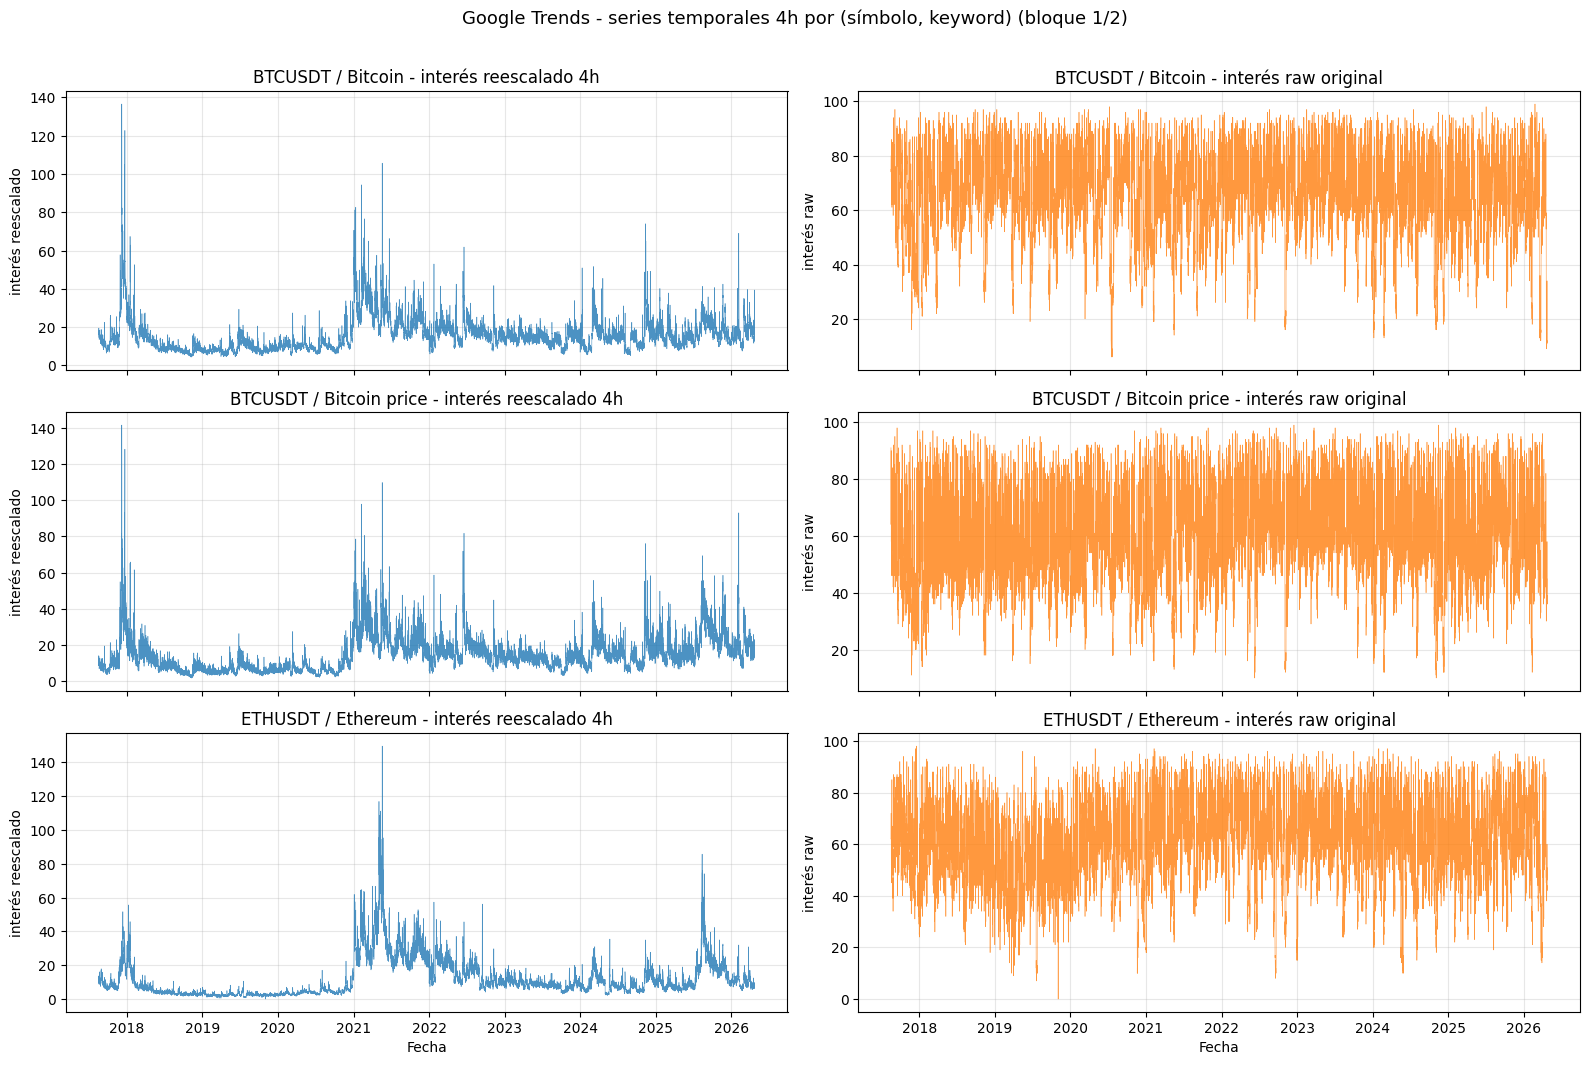

Figura guardada (bloque 1/2): /app/reports/validation/google_trends/figures/google_trends_series_4h_BLOCK1_20260603T231319Z.png


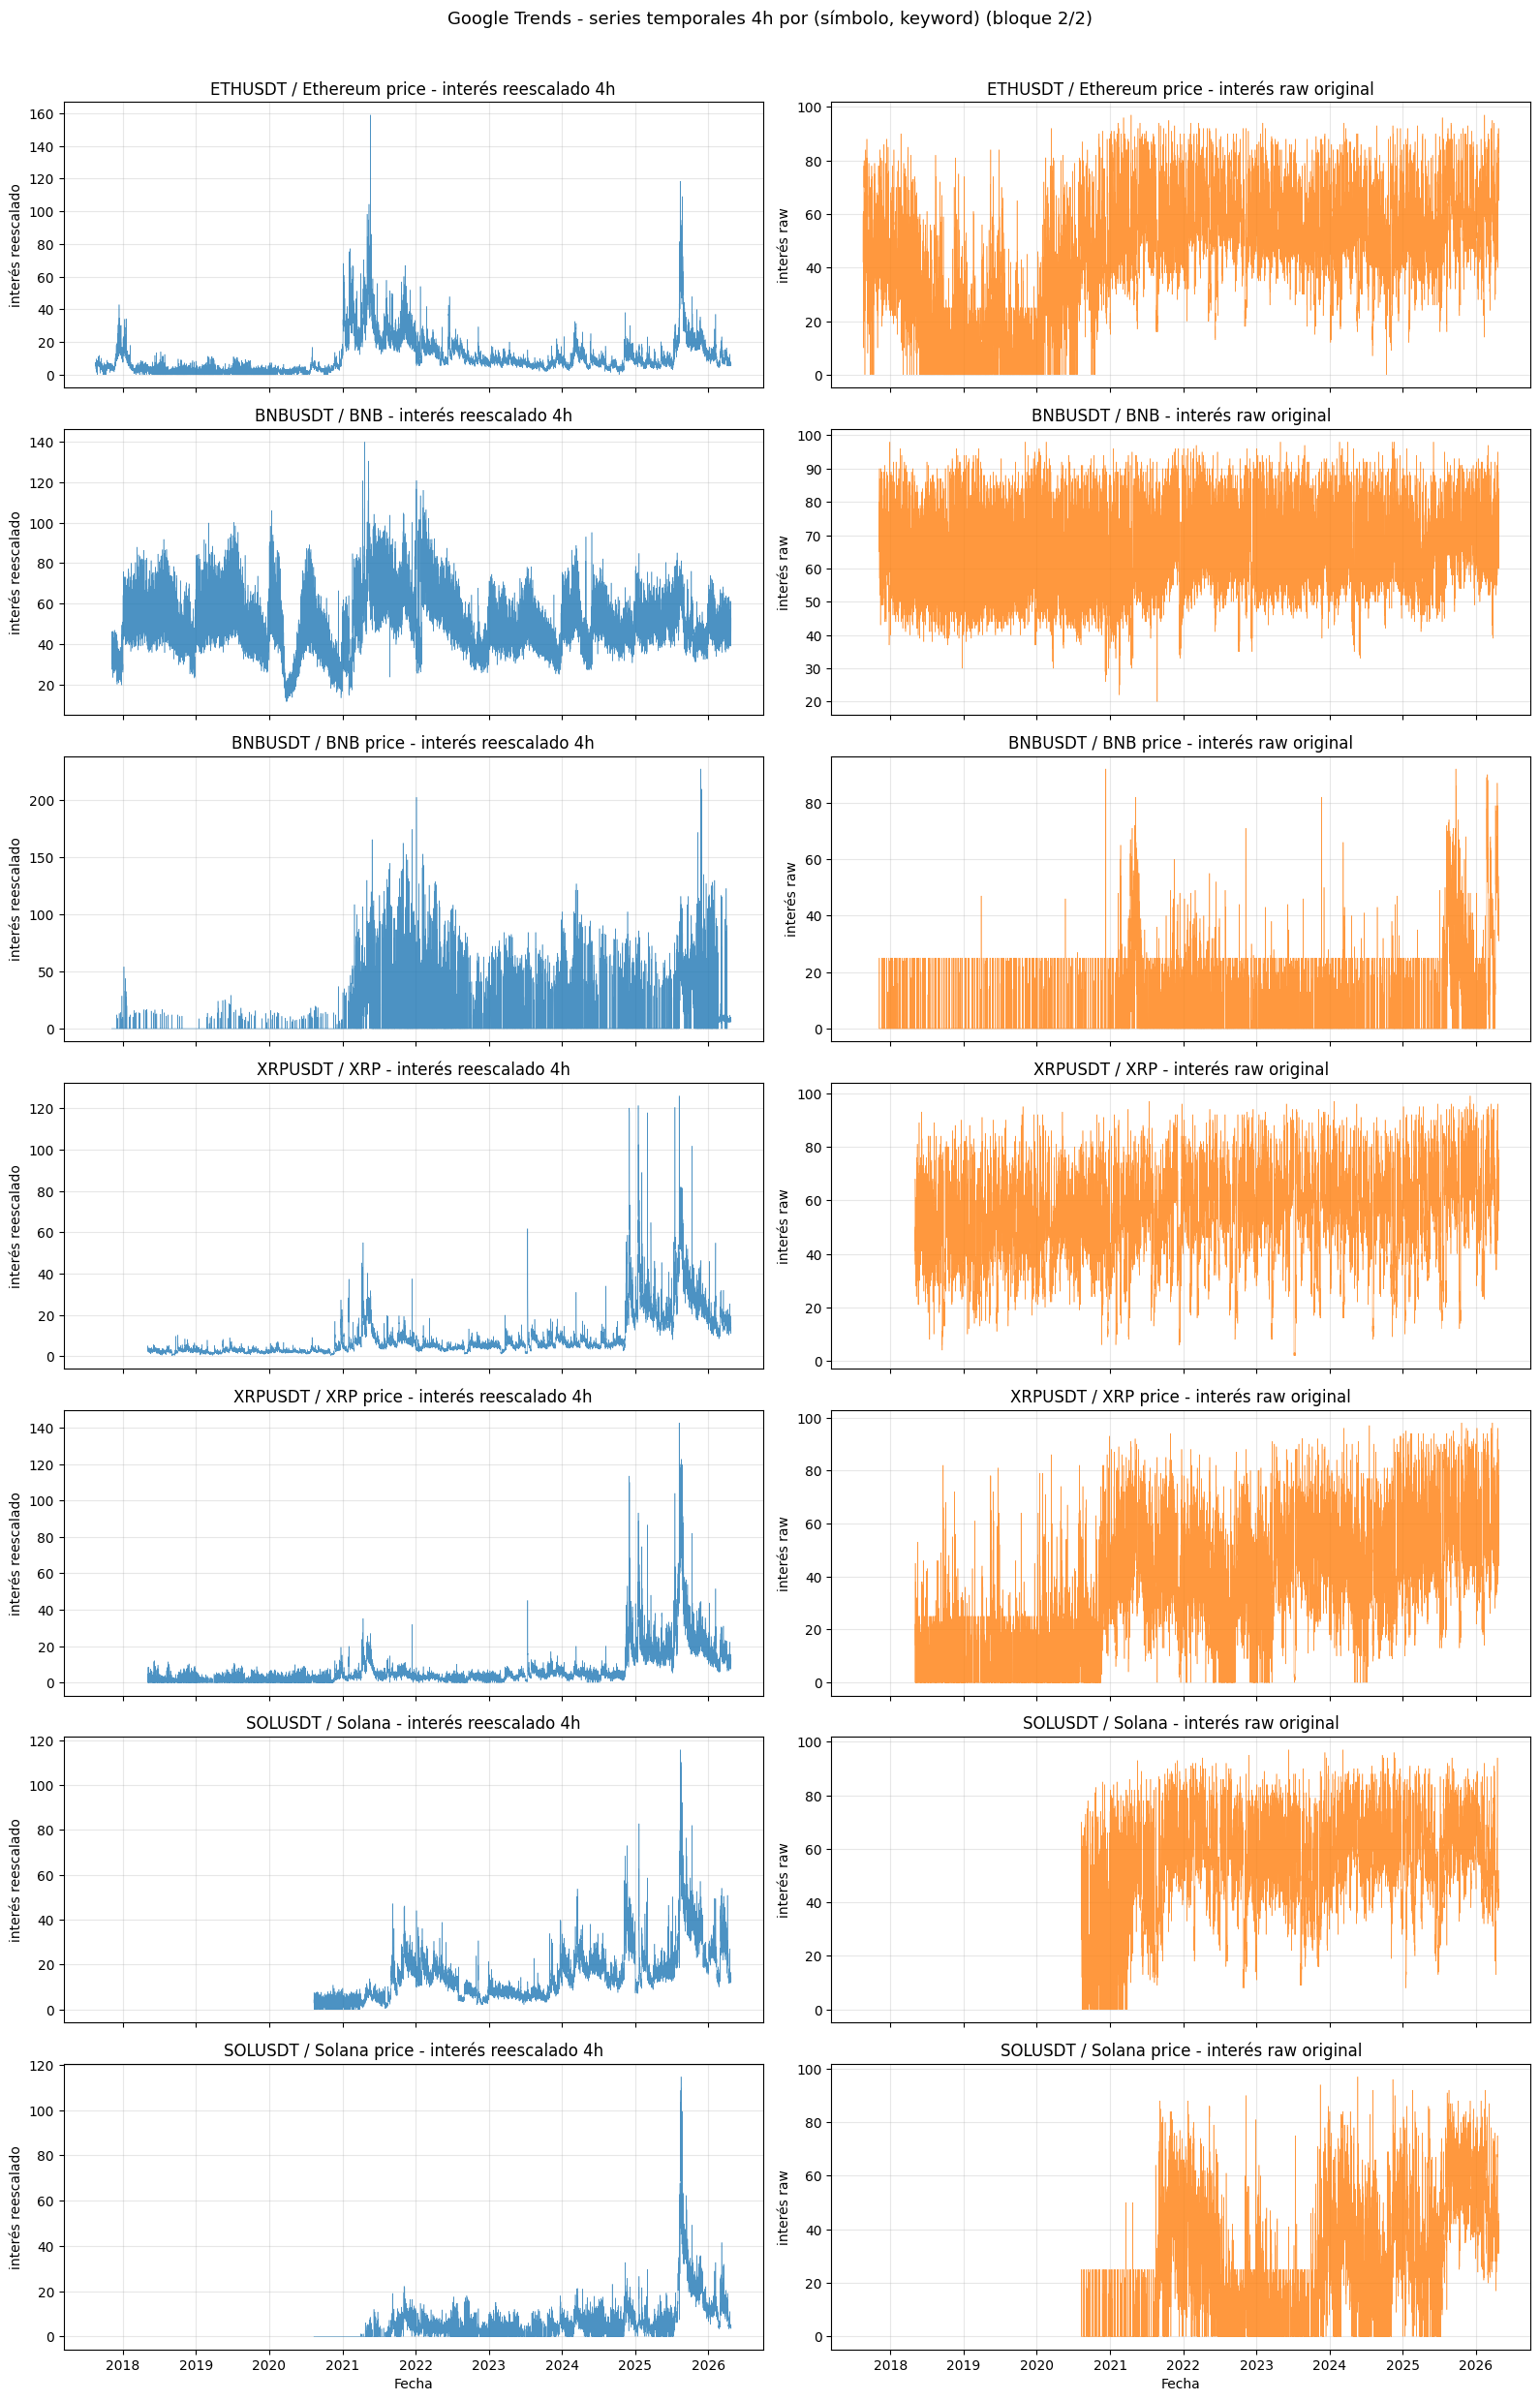

Figura guardada (bloque 2/2): /app/reports/validation/google_trends/figures/google_trends_series_4h_BLOCK2_20260603T231319Z.png


In [8]:
series_dict: dict[str, dict[str, pd.DataFrame]] = {}

if engine:
    for symbol in GOOGLE_TRENDS_SYMBOLS:
        series_dict[symbol] = {}
        for keyword in GOOGLE_TRENDS_KEYWORD_MAP.get(symbol, ()):
            q = text(
                f"""
                SELECT bucket_4h,
                       interest_rescaled,
                       interest_raw,
                       interest_daily,
                       interest_monthly
                FROM {GOOGLE_TRENDS_FULL_TABLE}
                WHERE symbol = :symbol AND keyword = :keyword
                ORDER BY bucket_4h
                """
            )
            df = pd.read_sql(q, engine, params={"symbol": symbol, "keyword": keyword})
            if not df.empty:
                df["bucket_4h"] = pd.to_datetime(df["bucket_4h"])
                series_dict[symbol][keyword] = df

# Mantiene un orden estable por símbolo y keyword
series_pares: list[tuple[str, str, pd.DataFrame]] = []
for symbol in GOOGLE_TRENDS_SYMBOLS:
    for keyword, df in series_dict.get(symbol, {}).items():
        series_pares.append((symbol, keyword, df))

pares_por_bloque = 3
fig_series_path_part1 = None
fig_series_path_part2 = None

if series_pares:
    bloques: list[list[tuple[str, str, pd.DataFrame]]] = [series_pares[:pares_por_bloque]]
    if len(series_pares) > pares_por_bloque:
        bloques.append(series_pares[pares_por_bloque:])

    for bloque_idx, bloque in enumerate(bloques, start=1):
        n_filas = len(bloque)
        fig, axes = plt.subplots(
            n_filas,
            2,
            figsize=(16, 3.5 * n_filas),
            sharex=True,
        )
        if n_filas == 1:
            axes = [axes]

        for fila_idx, (symbol, keyword, df) in enumerate(bloque):
            ax_reescalado, ax_raw = axes[fila_idx]

            ax_reescalado.plot(df["bucket_4h"], df["interest_rescaled"], linewidth=0.4, alpha=0.8)
            ax_reescalado.set_ylabel("interés reescalado")
            ax_reescalado.set_title(f"{symbol} / {keyword} - interés reescalado 4h")
            ax_reescalado.xaxis.set_major_locator(mdates.YearLocator())
            ax_reescalado.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            ax_reescalado.grid(True, alpha=0.3)

            ax_raw.plot(
                df["bucket_4h"],
                df["interest_raw"],
                linewidth=0.4,
                alpha=0.8,
                color="tab:orange",
            )
            ax_raw.set_ylabel("interés raw")
            ax_raw.set_title(f"{symbol} / {keyword} - interés raw original")
            ax_raw.xaxis.set_major_locator(mdates.YearLocator())
            ax_raw.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            ax_raw.grid(True, alpha=0.3)

        axes[-1][0].set_xlabel("Fecha")
        axes[-1][1].set_xlabel("Fecha")
        n_bloques = len(bloques)
        fig.suptitle(
            f"Google Trends - series temporales 4h por (símbolo, keyword) (bloque {bloque_idx}/{n_bloques})",
            fontsize=13,
            y=1.01,
        )
        plt.tight_layout()
        out_path = GOOGLE_TRENDS_FIGURES_DIR / f"google_trends_series_4h_BLOCK{bloque_idx}_{RUN_STAMP}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Figura guardada (bloque {bloque_idx}/{n_bloques}): {out_path}")

        if bloque_idx == 1:
            fig_series_path_part1 = out_path
        else:
            fig_series_path_part2 = out_path
else:
    print("Sin datos para graficar series temporales.")


### 5.2. Muestra de filas recientes

La muestra final por par permite comprobar la forma de los registros más recientes sin convertir el cuaderno en una exploración exhaustiva de la tabla completa.


In [9]:
muestras: dict[str, pd.DataFrame] = {}
COLUMNAS_MUESTRA_ES = {
    "symbol": "simbolo",
    "bucket_4h": "bucket_4h_utc",
    "interest_rescaled": "interes_reescalado",
    "interest_raw": "interes_raw",
    "interest_daily": "interes_diario",
    "interest_monthly": "interes_mensual",
    "is_imputed": "es_imputado",
    "ingested_at": "ingesta_utc",
}

if engine:
    for symbol in GOOGLE_TRENDS_SYMBOLS:
        for keyword in GOOGLE_TRENDS_KEYWORD_MAP.get(symbol, ()):
            q = text(
                f"""
                SELECT symbol, keyword, bucket_4h,
                       interest_rescaled, interest_raw,
                       interest_daily, interest_monthly,
                       is_imputed,
                       ingested_at
                FROM {GOOGLE_TRENDS_FULL_TABLE}
                WHERE symbol = :symbol AND keyword = :keyword
                ORDER BY bucket_4h DESC
                LIMIT 5
                """
            )
            key = f"{symbol} / {keyword}"
            muestras[key] = pd.read_sql(
                q, engine, params={"symbol": symbol, "keyword": keyword}
            ).rename(columns=COLUMNAS_MUESTRA_ES)

for key, df in muestras.items():
    print(f"Muestra reciente: {key}")
    display(df)


Muestra reciente: BTCUSDT / Bitcoin


,simbolo,keyword,bucket_4h_utc,interes_reescalado,interes_raw,interes_diario,interes_mensual,es_imputado,ingesta_utc
0,BTCUSDT,Bitcoin,2026-04-23 20:00:00+00:00,13.7105,12,17.6,22.0,False,2026-04-24 11:43:19.409354+00:00
1,BTCUSDT,Bitcoin,2026-04-23 16:00:00+00:00,13.4188,12,17.6,22.0,False,2026-04-24 11:43:19.409354+00:00
2,BTCUSDT,Bitcoin,2026-04-23 12:00:00+00:00,12.8354,11,17.6,22.0,False,2026-04-24 11:43:19.409354+00:00
3,BTCUSDT,Bitcoin,2026-04-23 08:00:00+00:00,12.5436,11,17.6,22.0,False,2026-04-24 11:43:19.409354+00:00
4,BTCUSDT,Bitcoin,2026-04-23 04:00:00+00:00,13.7105,12,17.6,22.0,False,2026-04-24 11:43:19.409354+00:00


Muestra reciente: BTCUSDT / Bitcoin price


,simbolo,keyword,bucket_4h_utc,interes_reescalado,interes_raw,interes_diario,interes_mensual,es_imputado,ingesta_utc
0,BTCUSDT,Bitcoin price,2026-04-23 20:00:00+00:00,15.4844,39,16.5,25.0,False,2026-04-24 11:44:16.518791+00:00
1,BTCUSDT,Bitcoin price,2026-04-23 16:00:00+00:00,15.1847,38,16.5,25.0,False,2026-04-24 11:44:16.518791+00:00
2,BTCUSDT,Bitcoin price,2026-04-23 12:00:00+00:00,15.6842,39,16.5,25.0,False,2026-04-24 11:44:16.518791+00:00
3,BTCUSDT,Bitcoin price,2026-04-23 08:00:00+00:00,14.5853,36,16.5,25.0,False,2026-04-24 11:44:16.518791+00:00
4,BTCUSDT,Bitcoin price,2026-04-23 04:00:00+00:00,14.9849,38,16.5,25.0,False,2026-04-24 11:44:16.518791+00:00


Muestra reciente: ETHUSDT / Ethereum


...

,simbolo,keyword,bucket_4h_utc,interes_reescalado,interes_raw,interes_diario,interes_mensual,es_imputado,ingesta_utc
0,XRPUSDT,XRP price,2026-04-23 20:00:00+00:00,13.1102,78,10.54,17.0,False,2026-04-24 11:53:57.412585+00:00
1,XRPUSDT,XRP price,2026-04-23 16:00:00+00:00,11.1773,66,10.54,17.0,False,2026-04-24 11:53:57.412585+00:00
2,XRPUSDT,XRP price,2026-04-23 12:00:00+00:00,10.2529,61,10.54,17.0,False,2026-04-24 11:53:57.412585+00:00
3,XRPUSDT,XRP price,2026-04-23 08:00:00+00:00,7.4375,44,10.54,17.0,False,2026-04-24 11:53:57.412585+00:00
4,XRPUSDT,XRP price,2026-04-23 04:00:00+00:00,8.4460,50,10.54,17.0,False,2026-04-24 11:53:57.412585+00:00


Muestra reciente: SOLUSDT / Solana


,simbolo,keyword,bucket_4h_utc,interes_reescalado,interes_raw,interes_diario,interes_mensual,es_imputado,ingesta_utc
0,SOLUSDT,Solana,2026-04-23 20:00:00+00:00,14.3004,45,13.8,30.0,False,2026-04-24 12:25:06.788590+00:00
1,SOLUSDT,Solana,2026-04-23 16:00:00+00:00,12.4832,40,13.8,30.0,False,2026-04-24 12:25:06.788590+00:00
2,SOLUSDT,Solana,2026-04-23 12:00:00+00:00,12.1672,38,13.8,30.0,False,2026-04-24 12:25:06.788590+00:00
3,SOLUSDT,Solana,2026-04-23 08:00:00+00:00,13.6683,43,13.8,30.0,False,2026-04-24 12:25:06.788590+00:00
4,SOLUSDT,Solana,2026-04-23 04:00:00+00:00,15.0905,48,13.8,30.0,False,2026-04-24 12:25:06.788590+00:00


Muestra reciente: SOLUSDT / Solana price


,simbolo,keyword,bucket_4h_utc,interes_reescalado,interes_raw,interes_diario,interes_mensual,es_imputado,ingesta_utc
0,SOLUSDT,Solana price,2026-04-23 20:00:00+00:00,4.5152,40,4.16,13.0,False,2026-04-24 12:28:58.582042+00:00
1,SOLUSDT,Solana price,2026-04-23 16:00:00+00:00,3.4495,31,4.16,13.0,False,2026-04-24 12:28:58.582042+00:00
2,SOLUSDT,Solana price,2026-04-23 12:00:00+00:00,3.6739,33,4.16,13.0,False,2026-04-24 12:28:58.582042+00:00
3,SOLUSDT,Solana price,2026-04-23 08:00:00+00:00,3.6739,33,4.16,13.0,False,2026-04-24 12:28:58.582042+00:00
4,SOLUSDT,Solana price,2026-04-23 04:00:00+00:00,4.5152,40,4.16,13.0,False,2026-04-24 12:28:58.582042+00:00


## 6. Inventario de artefactos Parquet en disco

El inventario contrasta los ficheros *raw* esperados para cada par `(símbolo, keyword)` con los artefactos disponibles en `data/01_raw/google_trends/`. Esta evidencia permite reconstruir la tabla sin depender de una nueva llamada a la fuente externa.


In [10]:
# Construye inventario de artefactos raw esperados
def slug_keyword(keyword: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", keyword.lower()).strip("_")


parquet_rows: list[dict] = []
for symbol in GOOGLE_TRENDS_SYMBOLS:
    for keyword in GOOGLE_TRENDS_KEYWORD_MAP.get(symbol, ()):
        raw_path = GOOGLE_TRENDS_RAW_DIR / f"google_trends_{symbol}_{slug_keyword(keyword)}.parquet"
        if raw_path.exists():
            tamano_mb = raw_path.stat().st_size / (1024 * 1024)
            try:
                raw_df = pd.read_parquet(raw_path)
                timestamps = (
                    pd.to_datetime(raw_df["bucket_4h"], errors="coerce", utc=True).dropna()
                    if "bucket_4h" in raw_df.columns
                    else pd.Series(dtype="datetime64[ns, UTC]")
                )
                parquet_rows.append({
                    "tipo": "raw_google_trends",
                    "simbolo": symbol,
                    "keyword": keyword,
                    "archivo": raw_path.name,
                    "tamano_mb": round(tamano_mb, 2),
                    "filas": len(raw_df),
                    "columnas": len(raw_df.columns),
                    "min_timestamp": timestamps.min() if not timestamps.empty else None,
                    "max_timestamp": timestamps.max() if not timestamps.empty else None,
                })
            except Exception:
                parquet_rows.append({
                    "tipo": "raw_google_trends",
                    "simbolo": symbol,
                    "keyword": keyword,
                    "archivo": raw_path.name,
                    "tamano_mb": round(tamano_mb, 2),
                    "filas": None,
                    "columnas": None,
                    "min_timestamp": None,
                    "max_timestamp": None,
                })
        else:
            parquet_rows.append({
                "tipo": "raw_google_trends",
                "simbolo": symbol,
                "keyword": keyword,
                "archivo": raw_path.name,
                "tamano_mb": None,
                "filas": None,
                "columnas": None,
                "min_timestamp": None,
                "max_timestamp": None,
            })

parquet_inventory_df = pd.DataFrame(parquet_rows)
display(parquet_inventory_df)


,tipo,simbolo,keyword,archivo,tamano_mb,filas,columnas,min_timestamp,max_timestamp
0,raw_google_trends,BTCUSDT,Bitcoin,google_trends_BTCUSDT_bitcoin.parquet,0.34,19032,13,2017-08-17 00:00:00+00:00,2026-04-23 20:00:00+00:00
1,raw_google_trends,BTCUSDT,Bitcoin price,google_trends_BTCUSDT_bitcoin_price.parquet,0.35,19032,13,2017-08-17 00:00:00+00:00,2026-04-23 20:00:00+00:00
2,raw_google_trends,ETHUSDT,Ethereum,google_trends_ETHUSDT_ethereum.parquet,0.35,19032,13,2017-08-17 00:00:00+00:00,2026-04-23 20:00:00+00:00
3,raw_google_trends,ETHUSDT,Ethereum price,google_trends_ETHUSDT_ethereum_price.parquet,0.33,19032,13,2017-08-17 00:00:00+00:00,2026-04-23 20:00:00+00:00
4,raw_google_trends,BNBUSDT,BNB,google_trends_BNBUSDT_bnb.parquet,0.34,18546,13,2017-11-06 00:00:00+00:00,2026-04-23 20:00:00+00:00
5,raw_google_trends,BNBUSDT,BNB price,google_trends_BNBUSDT_bnb_price.parquet,0.22,18546,13,2017-11-06 00:00:00+00:00,2026-04-23 20:00:00+00:00
6,raw_google_trends,XRPUSDT,XRP,google_trends_XRPUSDT_xrp.parquet,0.31,17472,13,2018-05-04 00:00:00+00:00,2026-04-23 20:00:00+00:00
7,raw_google_trends,XRPUSDT,XRP price,google_trends_XRPUSDT_xrp_price.parquet,0.29,17472,13,2018-05-04 00:00:00+00:00,2026-04-23 20:00:00+00:00
8,raw_google_trends,SOLUSDT,Solana,google_trends_SOLUSDT_solana.parquet,0.23,12492,13,2020-08-11 00:00:00+00:00,2026-04-23 20:00:00+00:00
9,raw_google_trends,SOLUSDT,Solana price,google_trends_SOLUSDT_solana_price.parquet,0.19,12492,13,2020-08-11 00:00:00+00:00,2026-04-23 20:00:00+00:00


## 7. Exportación de artefactos para reproducibilidad

Las tablas vistas son útiles dentro del cuaderno, pero la memoria del TFG y la auditoría externa necesitan **artefactos persistentes** en disco. En esta celda se vuelca todo lo anterior bajo `reports/validation/google_trends/`, con un timestamp UTC en el nombre para no sobrescribir corridas previas:

- Un **JSON consolidado** (`google_trends_validation_<stamp>.json`) que agrupa metadatos, fecha de corte del validador, universo de símbolos, mapa de keywords, resultado global, fallos accionables, matriz de comprobaciones, cobertura por keyword, `duplicados_pk`, `integridad_imputaciones`, consistencia, inventario Parquet y rutas de figuras.

- Siete **CSV** por bloque (mismo `<stamp>`, p. ej. `20260603T231319Z` en esta corrida): `summary`, `cobertura`, `resumen_simbolos`, `duplicados`, `integridad`, `consistencia`, `parquet_inventory`.

- Dos **PNG de series temporales** en `reports/validation/google_trends/figures/` (`google_trends_series_4h_BLOCK1_<stamp>.png`, `google_trends_series_4h_BLOCK2_<stamp>.png`), generados en la sección 5.

Al final se imprime el **resultado global** (`PASS`/`FAIL`), comprobaciones breves de **duplicados**, **integridad** e **inventario Parquet** *raw*, y las **rutas** del JSON, de los siete CSV y de las figuras exportadas.


In [11]:
# Exporta evidencia consolidada
export_paths = {
    "json": GOOGLE_TRENDS_OUTPUT_DIR / f"google_trends_validation_{RUN_STAMP}.json",
    "summary": GOOGLE_TRENDS_OUTPUT_DIR / f"google_trends_validation_summary_{RUN_STAMP}.csv",
    "cobertura": GOOGLE_TRENDS_OUTPUT_DIR / f"google_trends_validation_cobertura_{RUN_STAMP}.csv",
    "resumen_simbolos": GOOGLE_TRENDS_OUTPUT_DIR / f"google_trends_validation_resumen_simbolos_{RUN_STAMP}.csv",
    "duplicados": GOOGLE_TRENDS_OUTPUT_DIR / f"google_trends_validation_duplicados_{RUN_STAMP}.csv",
    "integridad": GOOGLE_TRENDS_OUTPUT_DIR / f"google_trends_validation_integridad_{RUN_STAMP}.csv",
    "consistencia": GOOGLE_TRENDS_OUTPUT_DIR / f"google_trends_validation_consistencia_{RUN_STAMP}.csv",
    "parquet_inventory": GOOGLE_TRENDS_OUTPUT_DIR / f"google_trends_validation_parquet_inventory_{RUN_STAMP}.csv",
}

duplicados_ok = bool(not duplicados_pk_df.empty and (duplicados_pk_df["duplicados_pk"] == 0).all())
integridad_ok = bool(not integridad_df.empty and len(integridad_df) == len(GOOGLE_TRENDS_SYMBOLS))
parquet_ok = bool(
    not parquet_inventory_df.empty
    and parquet_inventory_df["tamano_mb"].notna().sum() == len(parquet_inventory_df)
)

payload = {
    "metadata": run_meta,
    "fecha_corte": FECHA_CORTE,
    "simbolos": list(GOOGLE_TRENDS_SYMBOLS),
    "keywords_por_simbolo": {k: list(v) for k, v in GOOGLE_TRENDS_KEYWORD_MAP.items()},
    "resultado_global": "PASS" if accepted else "FAIL",
    "fallos_accionables": actionable_failures,
    "checks": summary_df.to_dict(orient="records"),
    "cobertura": {
        "detalle_por_keyword": evidencia_cobertura_df.to_dict(orient="records") if not evidencia_cobertura_df.empty else [],
    },
    "duplicados_pk": {
        "verificado": duplicados_ok,
        "cero_duplicados_todos_pares": duplicados_ok,
        "detalle": duplicados_pk_df.to_dict(orient="records") if not duplicados_pk_df.empty else [],
    },
    "integridad_imputaciones": {
        "verificado": integridad_ok,
        "detalle": integridad_df.to_dict(orient="records") if not integridad_df.empty else [],
    },
    "consistencia": consistencia_df.to_dict(orient="records") if not consistencia_df.empty else [],
    "inventario_parquet": {
        "archivos_encontrados": int(parquet_inventory_df["tamano_mb"].notna().sum()) if not parquet_inventory_df.empty else 0,
        "archivos_esperados": len(parquet_inventory_df) if not parquet_inventory_df.empty else 0,
        "detalle": parquet_inventory_df.to_dict(orient="records") if not parquet_inventory_df.empty else [],
    },
    "figuras": {
        "series_4h_png_bloque_1": str(fig_series_path_part1) if fig_series_path_part1 else None,
        "series_4h_png_bloque_2": str(fig_series_path_part2) if fig_series_path_part2 else None,
    },
}

export_paths["json"].write_text(json.dumps(payload, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
summary_df.to_csv(export_paths["summary"], index=False)
if not evidencia_cobertura_df.empty:
    evidencia_cobertura_df.to_csv(export_paths["cobertura"], index=False)
if not resumen_simbolos_df.empty:
    resumen_simbolos_df.to_csv(export_paths["resumen_simbolos"], index=False)
if not duplicados_pk_df.empty:
    duplicados_pk_df.to_csv(export_paths["duplicados"], index=False)
if not integridad_df.empty:
    integridad_df.to_csv(export_paths["integridad"], index=False)
if not consistencia_df.empty:
    consistencia_df.to_csv(export_paths["consistencia"], index=False)
if not parquet_inventory_df.empty:
    parquet_inventory_df.to_csv(export_paths["parquet_inventory"], index=False)

print(f"Resultado global: {'PASS' if accepted else 'FAIL'}")
print(f"Duplicados = 0 verificado: {'OK' if duplicados_ok else 'PENDIENTE'}")
print(f"Integridad por símbolo: {'OK' if integridad_ok else 'PENDIENTE'}")
print(f"Inventario Parquet completo: {'OK' if parquet_ok else 'PENDIENTE'}")
print(f"Evidencia JSON: {export_paths['json']}")
print(f"Resumen de comprobaciones CSV: {export_paths['summary']}")
print(f"Cobertura CSV: {export_paths['cobertura']}")
if not resumen_simbolos_df.empty:
    print(f"Resumen por símbolo CSV: {export_paths['resumen_simbolos']}")
if not duplicados_pk_df.empty:
    print(f"Duplicados PK CSV: {export_paths['duplicados']}")
if not integridad_df.empty:
    print(f"Integridad/imputaciones CSV: {export_paths['integridad']}")
if not consistencia_df.empty:
    print(f"Consistencia CSV: {export_paths['consistencia']}")
if not parquet_inventory_df.empty:
    print(f"Inventario Parquet CSV: {export_paths['parquet_inventory']}")
if fig_series_path_part1:
    print(f"Figura series 4h (bloque 1): {fig_series_path_part1}")
if fig_series_path_part2:
    print(f"Figura series 4h (bloque 2): {fig_series_path_part2}")

if engine:
    engine.dispose()


Resultado global: PASS
Duplicados = 0 verificado: OK
Integridad por símbolo: OK
Inventario Parquet completo: OK
Evidencia JSON: /app/reports/validation/google_trends/google_trends_validation_20260603T231319Z.json
Resumen de comprobaciones CSV: /app/reports/validation/google_trends/google_trends_validation_summary_20260603T231319Z.csv
Cobertura CSV: /app/reports/validation/google_trends/google_trends_validation_cobertura_20260603T231319Z.csv
Resumen por símbolo CSV: /app/reports/validation/google_trends/google_trends_validation_resumen_simbolos_20260603T231319Z.csv
Duplicados PK CSV: /app/reports/validation/google_trends/google_trends_validation_duplicados_20260603T231319Z.csv
Integridad/imputaciones CSV: /app/reports/validation/google_trends/google_trends_validation_integridad_20260603T231319Z.csv
Consistencia CSV: /app/reports/validation/google_trends/google_trends_validation_consistencia_20260603T231319Z.csv
Inventario Parquet CSV: /app/reports/validation/google_trends/google_trends_

## 8. Conclusiones

Para el universo `{BTCUSDT, ETHUSDT, BNBUSDT, XRPUSDT, SOLUSDT}` y fecha de corte **2026-02-28**, la ejecución (`stamp` `20260603T231319Z`, `fecha_hora_utc` **2026-06-03 23:13 UTC**) deja una lectura favorable de la ingesta de Google Trends.

1. **Ingesta estructural**: la matriz de aceptación aparece en `PASS`, con 10 checks en `PASS`, 0 en `FAIL` y 0 en `SKIP`. No se registran fallos accionables en el validador.

2. **Cobertura e integridad**: la tabla `alternative_data.fact_google_trends` queda resumida en los cinco símbolos del universo y en **10** pares (símbolo, *keyword*), con **173,148** filas agregadas entre el mínimo global **2017-08-17 00:00 UTC** y el máximo **2026-04-23 20:00 UTC** (cada par puede iniciar más tarde). La comprobación de clave primaria suma **0** duplicados. La integridad distingue **173,148** filas reales frente a **0** imputadas.

3. **Artefactos**: se localizan **10** de **10** artefactos Parquet *raw* esperados y se exportan el JSON consolidado, siete CSV de evidencia y dos figuras 4h bajo `reports/validation/google_trends/` (`google_trends_series_4h_BLOCK1_20260603T231319Z.png`, `BLOCK2_...` con el mismo `stamp`).

4. **Limitación interpretativa**: *Google Trends* aporta una señal auxiliar de atención relativa, dependiente del término consultado y del reescalado mensual, diario y horario antes de la agregación a 4h. Por tanto, la fuente complementa las capas de mercado, pero no sustituye precio, volumen ni otras señales observacionales directas.

**Nota.** Las cifras y rutas citadas dependen del estado del proyecto en el momento de ejecutar el cuaderno; en otra corrida pueden cambiar valores, `stamp` y lectura.
